<font color=#009afa size=50>[Project Title]</font><br>
<font size=50>[Project Subtitle]</font><br>
<font size=20 color=#00c382>1 - Data Exploration and Cleaning</font><br>

|**Assessment Code:** |[Code]|
|---|---|
|**Author:**|[Author(s)]|
|**Course:**|[Course Code]|
|**Course Tutor:**|[Supervisor]|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**


---

# Initialise Notebook

In [1]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [25]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime
import re

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [26]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [27]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

string_padding - Custom padding function

In [28]:
# Adds string padding to a string (left or right side)
def string_padding (a_string, length,side="right"):
    if len(a_string) < length:
        # Pad the string with spaces
        if side == "left":
            # Pad on the left
            return " " * (length - len(a_string)) + a_string        
        else:
            return a_string + " " * (length - len(a_string))    
    else:
        # Truncate the string to the specified length
        return a_string[:length]
    


print_results_table - Create a custom results table

In [29]:
# Print Results Table
def print_results_table (results, table_title = "Results", padding=16):

    # Set the padding value
    padding_value = padding

    if len(results) < 1:
        print (Fore.RED + "No results found" + Style.RESET_ALL)
    else:
        print ("")
        print (Fore.YELLOW + table_title + Style.RESET_ALL)

        header_fields = list(results[0].keys())

        header_row = ""
        for f in header_fields:
            #header_row = string_padding(f, len(str(results[0][f])),side='left')
            header_row += string_padding(f, padding_value,side='left')
        print ((len(header_row)+2) * "-")
        print (header_row)
        print ((len(header_row)+2) * "-")

        # Print each row of the results in alternating stripes
        row_count = 0
        for row in results:
            row_str = ""
            for f in header_fields:
                row_str += string_padding(str(row[f]), padding_value,side='left')
            if row_count % 2 == 0:
                print (Fore.CYAN + row_str + Style.RESET_ALL)
            else:   
                print (Fore.WHITE + row_str + Style.RESET_ALL)
            row_count += 1

        print ((len(header_row)+2) * "-")
        print ("Total Results: ", len(results))
        print ((len(header_row)+2) * "-")
        print ("")

### Check for Internet Access

In [30]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [31]:
internet_required = True

In [32]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load and Explore the Dataset

In [33]:
# Load the dataset from local file
df = pd.read_excel('../datasets/UnitPersonnelAgeAtDate.xlsx', header=3)
df = df.dropna(axis=1, how='all')
if 'Unnamed: 0' in df.columns:
    df = df.rename(columns={'Unnamed: 0': 'Rank'})

### Explore the dataset

In [34]:
print (df.columns)
print ("")
print (df.shape)

Index(['Rank', 'Name', 'Age At', 'Age Now'], dtype='str')

(33, 4)


# Feature Engineering

In [40]:
# Names
df[['Surname', 'First Name']] = df['Name'].str.split(', ', expand=True)

def extract_years(age_str):
    if pd.isna(age_str) or not isinstance(age_str, str):
        return None
    # Find the digits immediately followed by 'y'
    match = re.search(r'(\d+)y', age_str)
    return int(match.group(1)) if match else None

# 3. Create the new field 'Age_Years'
df['Age Years'] = df['Age Now'].apply(extract_years)



---

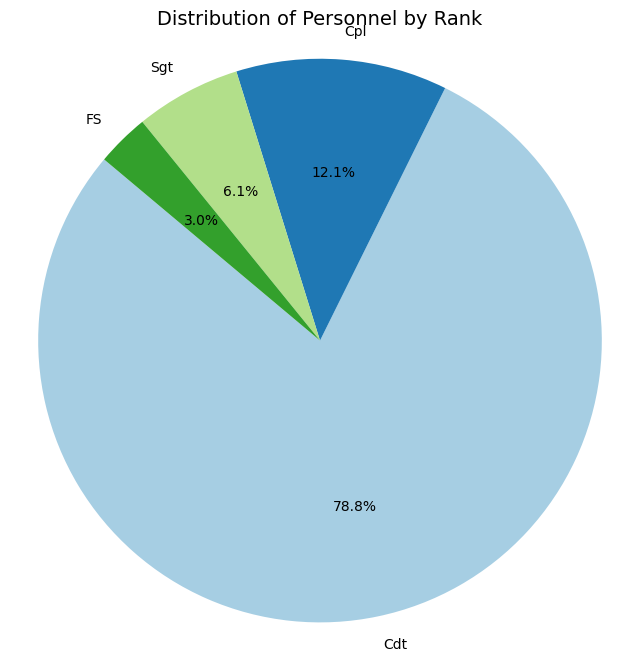

In [41]:
# 2. Count how many people are in each Rank
rank_counts = df['Rank'].value_counts()

# 3. Create the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(rank_counts, 
        labels=rank_counts.index, 
        autopct='%1.1f%%',      # Shows the percentage on the slice
        startangle=140,         # Rotates the start of the chart
        colors=plt.cm.Paired.colors) # Uses a standard color palette

plt.title('Distribution of Personnel by Rank', fontsize=14)
plt.axis('equal')  # Ensures the pie chart is a perfect circle

# 4. Save and display
plt.savefig('rank_distribution_pie_chart.png')
plt.show()

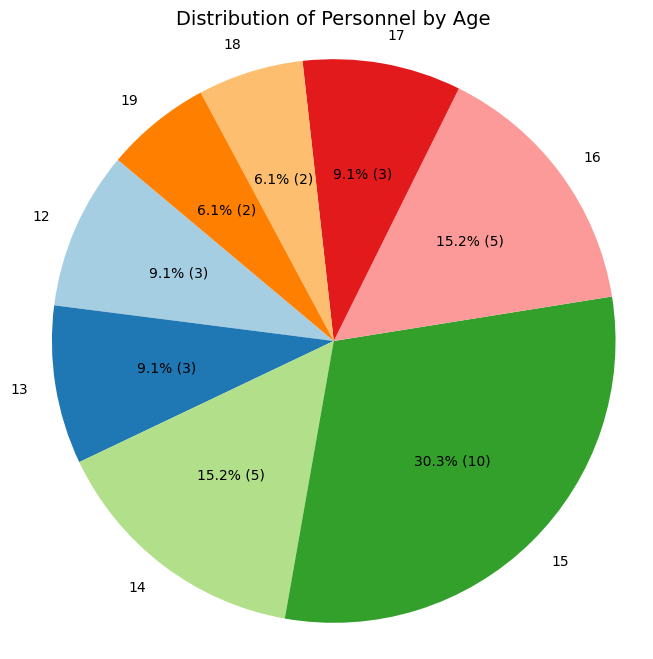

In [45]:
# Count how many people are in each Age
age_counts = df['Age Years'].value_counts().sort_index()

# 3. Create the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(age_counts, 
        labels=age_counts.index, 
        autopct=lambda pct: f'{pct:.1f}% ({int(round(pct * age_counts.sum() / 100.0))})',
        startangle=140,         # Rotates the start of the chart
        colors=plt.cm.Paired.colors) # Uses a standard color palette

plt.title('Distribution of Personnel by Age', fontsize=14)
plt.axis('equal')  # Ensures the pie chart is a perfect circle

# 4. Save and display
plt.savefig('age_distribution_pie_chart.png')
plt.show()

In [49]:
def get_months_to_18(age_str):
    if pd.isna(age_str) or not isinstance(age_str, str):
        return None
    
    # Extract years, months, and days
    y = int(re.search(r'(\d+)y', age_str).group(1)) if 'y' in age_str else 0
    m = int(re.search(r'(\d+)m', age_str).group(1)) if 'm' in age_str else 0
    d = int(re.search(r'(\d+)d', age_str).group(1)) if 'd' in age_str else 0
    
    # Calculate total months lived (approx 30.44 days per month)
    total_months_lived = (y * 12) + m + (d / 30.44)
    
    # Target is 18 years (216 months)
    remaining_months = 216 - total_months_lived
    return round(remaining_months, 1)

# 3. Add the new column
df['Months to 18'] = df['Age Now'].apply(get_months_to_18)

# 4. Filter for 17-year-olds (includes any rank)
# Note: In your snippet, the 17-year-old is a Corporal (Cpl)
age_17_table = df[df['Age Now'].str.contains('17y')]

# 5. Display the result
print(age_17_table[['Rank', 'Name', 'Age Now', 'Months to 18']])

   Rank           Name      Age Now  Months to 18
2   Cpl   Bolohan, Jay  17y 03m 20d           8.3
26  Cdt    Price, Liam  17y 06m 22d           5.3
30  Cpl  Smith, Joshua  17y 10m 03d           1.9


# Data Cleaning


...do stuff...

### Write out the cleaned dataset for further use



In [43]:
# Create filenames, one timestamped, one 'latest'
filepath = "../datasets"
filename = f'{filepath}/the_dataset_name_{now_date_timestamp}.csv'
latest_filename = f'{filepath}/the_dataset_name_latest.csv'

# Write out CSV files
df.to_csv(filename, index=False)
df.to_csv(latest_filename, index=False)